In [98]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
    silhouette_score, confusion_matrix, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)


In [99]:
# 1) Загрузка данных

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Домашние работы МО/Churn_Modelling.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Не найден файл: {DATA_PATH}\n"
        "Загрузи CSV в Colab (панель Files -> Upload) или поменяй путь DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Размер:", df.shape)

Размер: (10002, 14)


In [100]:
# 2) Разделение на признаки X и истинную метку y_true

TARGET_COL = "Exited"

if TARGET_COL not in df.columns:
    raise ValueError(f"Не найдена целевая колонка '{TARGET_COL}'. Проверь названия колонок.")

y_true = df[TARGET_COL].astype(int).to_numpy()

X = df.drop(columns=[TARGET_COL])

# Удаляем идентификаторы, они вредны для обучения
drop_cols = [c for c in ["RowNumber", "CustomerId", "Surname"] if c in X.columns]
X = X.drop(columns=drop_cols)

print("Удаленные колонки:", drop_cols)
print("X:", X.shape, "y_true:", y_true.shape)
display(X.head())


Удаленные колонки: ['RowNumber', 'CustomerId', 'Surname']
X: (10002, 10) y_true: (10002,)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88
1,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58
2,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57
3,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63
4,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10


Столбцы с пропусками: 4


,0
Geography,1
Age,1
IsActiveMember,1
HasCrCard,1


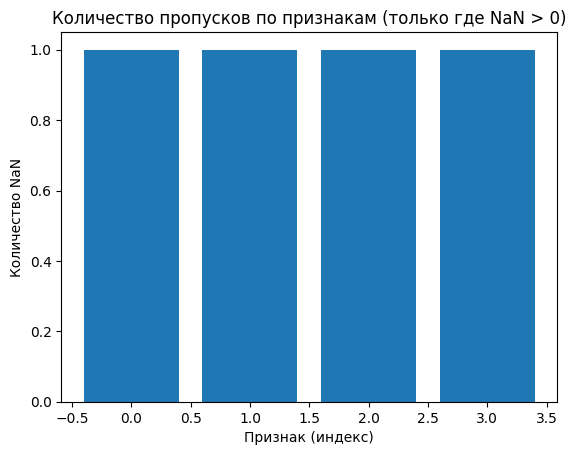

In [101]:
# 3) Быстрый EDA: пропуски и распределение истинной метки

# Пропуски по столбцам
na_counts = X.isna().sum().sort_values(ascending=False)
na_counts_nonzero = na_counts[na_counts > 0]

print("Столбцы с пропусками:", len(na_counts_nonzero))
if len(na_counts_nonzero) > 0:
    display(na_counts_nonzero)

    # Бар-чарт пропусков (только столбцы, где есть NaN)
    plt.figure()
    plt.bar(range(len(na_counts_nonzero)), na_counts_nonzero.values)
    plt.title("Количество пропусков по признакам (только где NaN > 0)")
    plt.xlabel("Признак (индекс)")
    plt.ylabel("Количество NaN")
    plt.show()
else:
    print("Пропусков в X не обнаружено.")

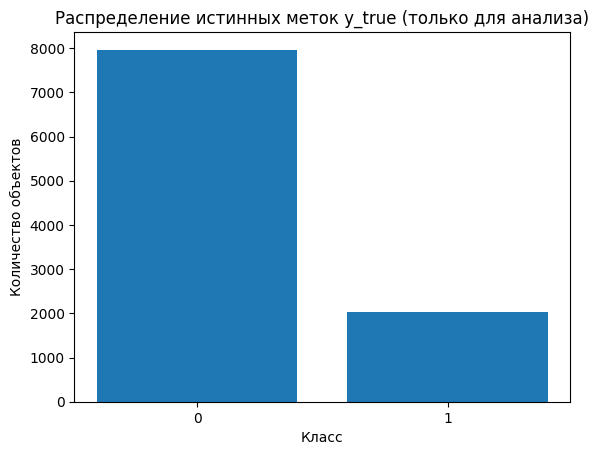

Доли классов: {0: 0.7962407518496301, 1: 0.20375924815036991}


In [102]:
# Распределение истинных классов
counts = pd.Series(y_true).value_counts().sort_index()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Распределение истинных меток y_true (только для анализа)")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.show()

print("Доли классов:", (counts / counts.sum()).to_dict())


In [103]:
# 4) Препроцессинг X
#    - числовые: median impute + StandardScaler
#    - категориальные: most_frequent impute + OneHot

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Категориальные:", cat_cols)
print("Числовые:", num_cols)

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
)

X_pre = preprocess.fit_transform(X)

# PCA и кластеризация удобнее на dense
X_pre = X_pre.toarray() if hasattr(X_pre, "toarray") else X_pre
X_pre = np.nan_to_num(X_pre, nan=0.0, posinf=0.0, neginf=0.0)

print("X_pre shape:", X_pre.shape)
print("NaN:", np.isnan(X_pre).sum(), "Inf:", np.isinf(X_pre).sum())


Категориальные: ['Geography', 'Gender']
Числовые: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
X_pre shape: (10002, 13)
NaN: 0 Inf: 0


PCA(0.95) -> компоненты: 10
Суммарная объясненная дисперсия: 0.9777835653802818


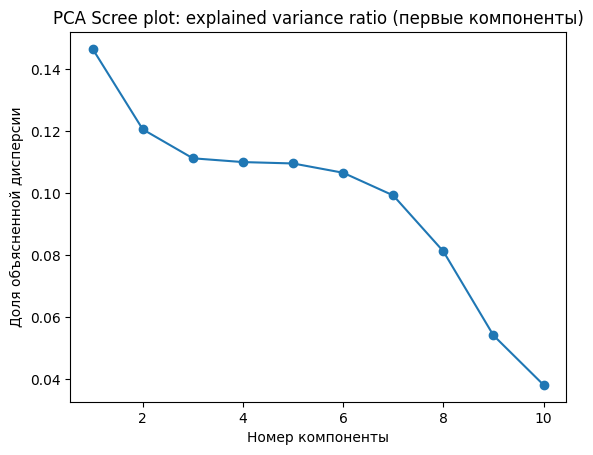

In [104]:
# 5) PCA

# PCA для кластеризации
pca95 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca95 = pca95.fit_transform(X_pre)

print("PCA(0.95) -> компоненты:", X_pca95.shape[1])
print("Суммарная объясненная дисперсия:", pca95.explained_variance_ratio_.sum())

# Scree plot (первые 30 компонент или меньше)
expl = pca95.explained_variance_ratio_
k = min(30, len(expl))

plt.figure()
plt.plot(range(1, k+1), expl[:k], marker="o")
plt.title("PCA Scree plot: explained variance ratio (первые компоненты)")
plt.xlabel("Номер компоненты")
plt.ylabel("Доля объясненной дисперсии")
plt.show()

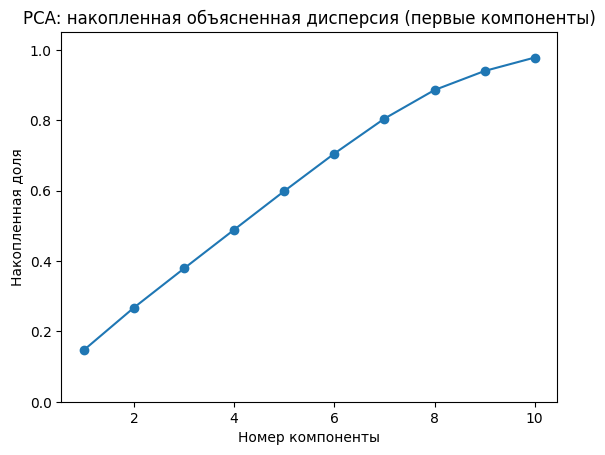

In [105]:
plt.figure()
plt.plot(range(1, k+1), np.cumsum(expl[:k]), marker="o")
plt.title("PCA: накопленная объясненная дисперсия (первые компоненты)")
plt.xlabel("Номер компоненты")
plt.ylabel("Накопленная доля")
plt.ylim(0, 1.05)
plt.show()


In [106]:
# PCA 2D только для графиков
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_pre)

print("PCA2 explained variance:", pca2.explained_variance_ratio_, "sum:", pca2.explained_variance_ratio_.sum())


PCA2 explained variance: [0.14662041 0.12064743] sum: 0.2672678371825639


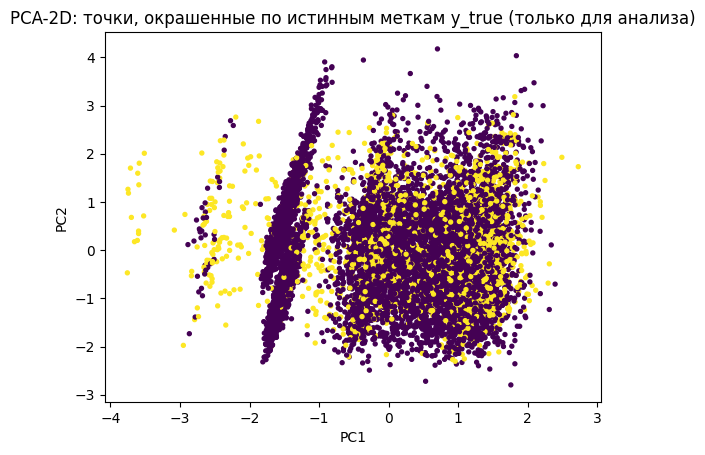

In [107]:
# Визуализация истинных меток в PCA-2D
plt.figure()
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_true, s=8)
plt.title("PCA-2D: точки, окрашенные по истинным меткам y_true (только для анализа)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

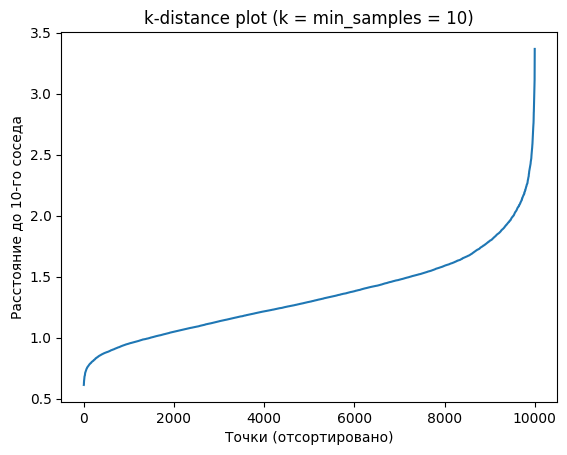

Эвристика eps (90-й процентиль k-distance): 1.7925


In [108]:
# 6) DBSCAN

def plot_k_distance(X_space, min_samples=10):
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_space)
    distances, _ = nbrs.kneighbors(X_space)
    k_dist = np.sort(distances[:, -1])

    plt.figure()
    plt.plot(k_dist)
    plt.title(f"k-distance plot (k = min_samples = {min_samples})")
    plt.xlabel("Точки (отсортировано)")
    plt.ylabel(f"Расстояние до {min_samples}-го соседа")
    plt.show()

    eps_guess = float(np.percentile(k_dist, 90))
    print(f"Эвристика eps (90-й процентиль k-distance): {eps_guess:.4f}")
    return eps_guess

eps_guess = plot_k_distance(X_pca95, min_samples=10)


KMeans: уникальные метки -> {np.int32(0): np.int64(5937), np.int32(1): np.int64(4065)}
Agglomerative: уникальные метки -> {np.int64(0): np.int64(7319), np.int64(1): np.int64(2683)}
DBSCAN: уникальные метки -> {np.int64(-1): np.int64(327), np.int64(0): np.int64(3517), np.int64(1): np.int64(1453), np.int64(2): np.int64(1335), np.int64(3): np.int64(3353), np.int64(4): np.int64(8), np.int64(5): np.int64(9)}


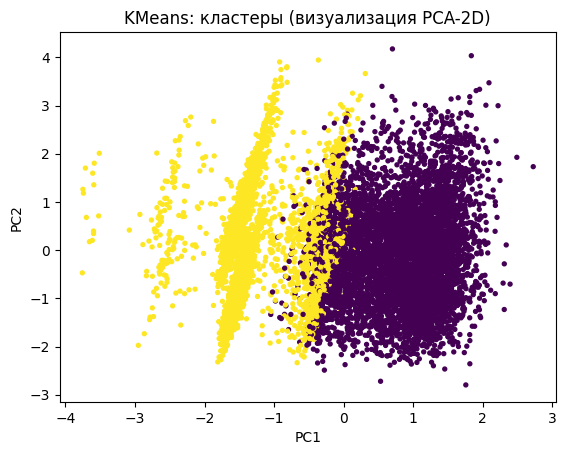

In [109]:
# 7) Обучение кластеризации

# --- KMeans ---
kmeans = KMeans(n_clusters=2, n_init="auto", random_state=RANDOM_STATE)
labels_kmeans = kmeans.fit_predict(X_pca95)

# --- Agglomerative ---
agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels_agg = agg.fit_predict(X_pca95)

# --- DBSCAN ---
dbscan = DBSCAN(eps=eps_guess, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_pca95)

def summarize_labels(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"{name}: уникальные метки ->", dict(zip(unique, counts)))

summarize_labels("KMeans", labels_kmeans)
summarize_labels("Agglomerative", labels_agg)
summarize_labels("DBSCAN", labels_dbscan)

def plot_clusters_2d(X2, labels, title):
    plt.figure()
    plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=8)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

plot_clusters_2d(X_pca2, labels_kmeans, "KMeans: кластеры (визуализация PCA-2D)")


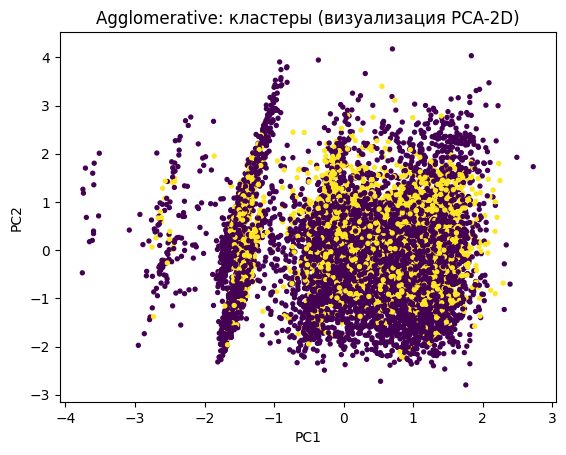

In [110]:
plot_clusters_2d(X_pca2, labels_agg, "Agglomerative: кластеры (визуализация PCA-2D)")

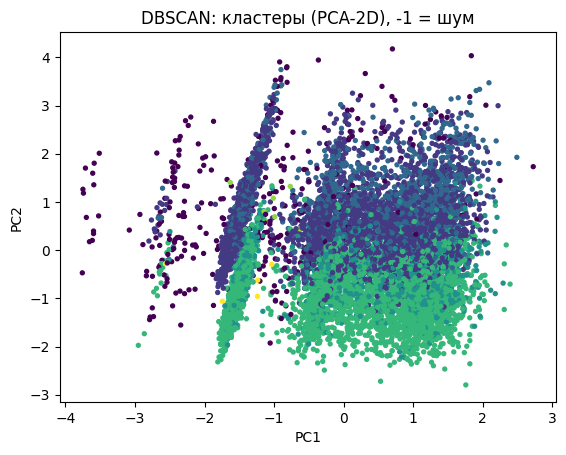

In [111]:
plot_clusters_2d(X_pca2, labels_dbscan, "DBSCAN: кластеры (PCA-2D), -1 = шум")

In [112]:
# 8) Оценка

def safe_silhouette(X_space, labels):
    """
    Silhouette требует >=2 кластеров.
    Для DBSCAN исключаем шум (-1), если возможно.
    """
    labels = np.asarray(labels)
    try:
        if -1 in labels:
            mask = labels != -1
            labs = labels[mask]
            if mask.sum() > 10 and len(np.unique(labs)) >= 2:
                return float(silhouette_score(X_space[mask], labs))
            return np.nan
        else:
            if len(np.unique(labels)) >= 2:
                return float(silhouette_score(X_space, labels))
            return np.nan
    except Exception:
        return np.nan


def majority_vote_map(labels, y_true):
    """Кластер -> класс по правилу большинства (только для оценки)."""
    labels = np.asarray(labels)
    y_true = np.asarray(y_true)

    mapped = np.empty_like(labels, dtype=int)
    for cl in np.unique(labels):
        idx = labels == cl
        if idx.sum() == 0:
            continue
        mapped


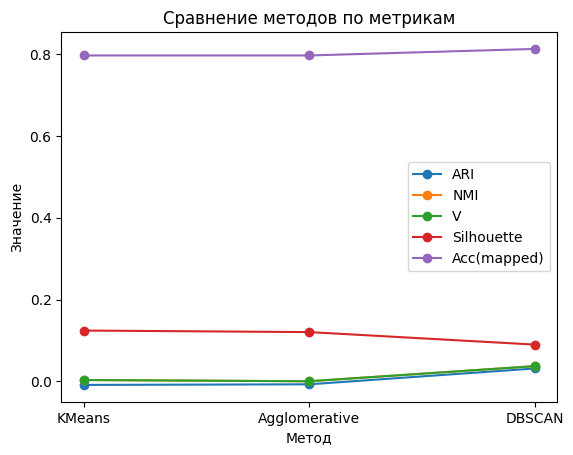

In [113]:
metric_names = ["ARI", "NMI", "V", "Silhouette", "Acc(mapped)"]

plt.figure()
x = np.arange(len(results_df.index))
for m in metric_names:
    vals = results_df[m].to_numpy()
    plt.plot(x, vals, marker="o", label=m)

plt.title("Сравнение методов по метрикам")
plt.xticks(x, results_df.index)
plt.xlabel("Метод")
plt.ylabel("Значение")
plt.legend()
plt.show()

min_samples = 10
eps_values = np.linspace(max(1e-6, eps_guess * 0.5), eps_guess * 1.5, 10)

n_clusters_list, noise_frac_list, sil_list = [], [], []

for eps in eps_values:
    model = DBSCAN(eps=float(eps), min_samples=min_samples)
    lbl = model.fit_predict(X_pca95)

    n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise_frac = float(np.mean(lbl == -1)) if (-1 in lbl) else 0.0
    sil = safe_silhouette(X_pca95, lbl)   # <-- ВАЖНО: без name=

    n_clusters_list.append(n_clusters)
    noise_frac_list.append(noise_frac)
    sil_list.append(sil)


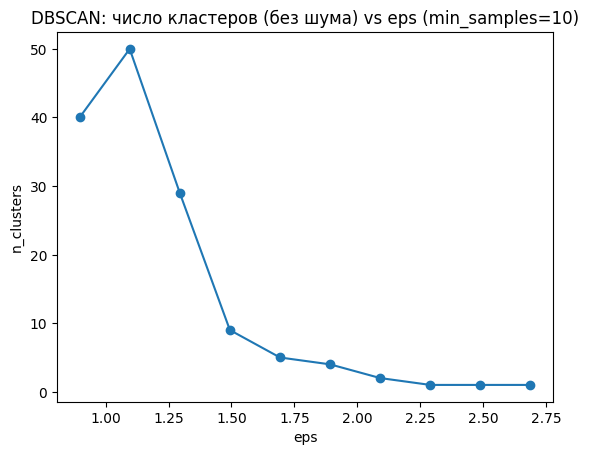

In [114]:
plt.figure()
plt.plot(eps_values, n_clusters_list, marker="o")
plt.title(f"DBSCAN: число кластеров (без шума) vs eps (min_samples={min_samples})")
plt.xlabel("eps")
plt.ylabel("n_clusters")
plt.show()

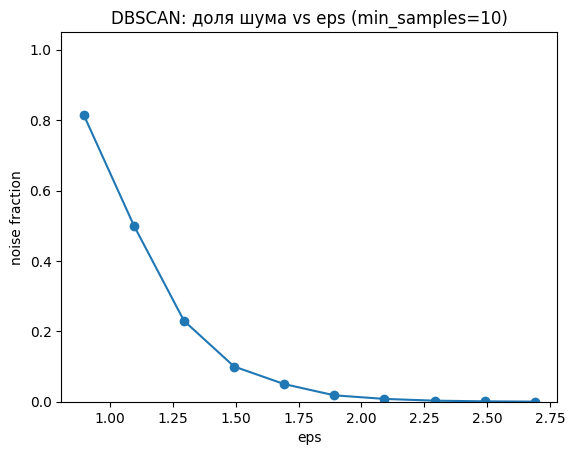

In [115]:
plt.figure()
plt.plot(eps_values, noise_frac_list, marker="o")
plt.title(f"DBSCAN: доля шума vs eps (min_samples={min_samples})")
plt.xlabel("eps")
plt.ylabel("noise fraction")
plt.ylim(0, 1.05)
plt.show()

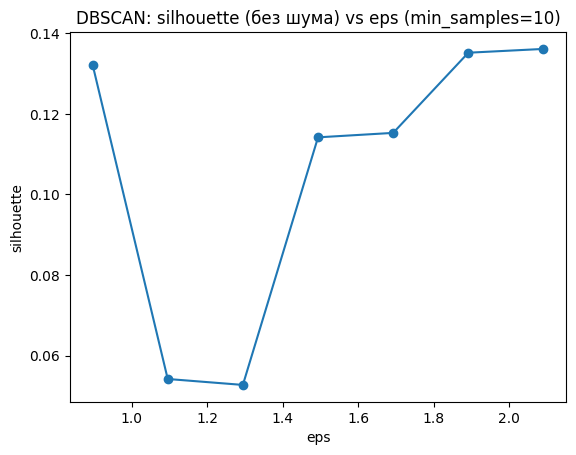

In [116]:
plt.figure()
plt.plot(eps_values, sil_list, marker="o")
plt.title(f"DBSCAN: silhouette (без шума) vs eps (min_samples={min_samples})")
plt.xlabel("eps")
plt.ylabel("silhouette")
plt.show()

In [117]:
# =========================================
# 10) Итоговые выводы (робастно к названиям колонок)
# =========================================

def pick_col(df, candidates):
    """Вернуть первое существующее имя колонки из списка candidates или None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

best_by_ari = results_df["ARI"].idxmax()
best_by_nmi = results_df["NMI"].idxmax()
best_by_v   = results_df["V"].idxmax()

# Находим, как у тебя реально называется колонка с числом кластеров
col_k = pick_col(results_df, ["n_clusters", "n_clusters(excl_noise)"])
col_noise = pick_col(results_df, ["noise_frac", "noise fraction"])

print("\n" + "="*70)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("-"*70)

print("1) Кластеризация выполнялась без учителя: при обучении использовались только признаки X.")
print("   Истинные метки y_true применялись исключительно после обучения для оценки качества.\n")

print("2) Лучшее совпадение с истинными метками (чем больше — тем лучше):")
print(f"   • Лучший по ARI: {best_by_ari}  (ARI={results_df.loc[best_by_ari,'ARI']:.3f})")
print(f"   • Лучший по NMI: {best_by_nmi}  (NMI={results_df.loc[best_by_nmi,'NMI']:.3f})")
print(f"   • Лучший по V-measure: {best_by_v} (V={results_df.loc[best_by_v,'V']:.3f})\n")

print("3) Интерпретация методов:")
print("   • KMeans и Agglomerative делят данные на фиксированное число кластеров (здесь 2),")
print("     поэтому дают стабильное разбиение, но могут навязать разделение при слабой структуре.")
print("   • DBSCAN выделяет плотные группы и может помечать часть объектов как шум (-1);")
print("     качество сильно зависит от eps и min_samples.\n")

if "DBSCAN" in results_df.index:
    if col_k is not None:
        k = int(results_df.loc["DBSCAN", col_k])
        print(f"4) DBSCAN: число кластеров (без шума): {k}")
    if col_noise is not None:
        noise = float(results_df.loc["DBSCAN", col_noise])
        print(f"   DBSCAN: доля шума: {noise:.1%}")
    print("   Если шума слишком много — eps маловат; если всё слилось в 1 кластер — eps великоват.\n")

print("5) Практический вывод:")
print("   Выбираем метод с наибольшими ARI/NMI/V и дополнительно проверяем адекватность разбиения")
print("   по PCA-визуализации и (для DBSCAN) доле шума.")
print("="*70)



ИТОГОВЫЕ ВЫВОДЫ
----------------------------------------------------------------------
1) Кластеризация выполнялась без учителя: при обучении использовались только признаки X.
   Истинные метки y_true применялись исключительно после обучения для оценки качества.

2) Лучшее совпадение с истинными метками (чем больше — тем лучше):
   • Лучший по ARI: DBSCAN  (ARI=0.031)
   • Лучший по NMI: DBSCAN  (NMI=0.037)
   • Лучший по V-measure: DBSCAN (V=0.037)

3) Интерпретация методов:
   • KMeans и Agglomerative делят данные на фиксированное число кластеров (здесь 2),
     поэтому дают стабильное разбиение, но могут навязать разделение при слабой структуре.
   • DBSCAN выделяет плотные группы и может помечать часть объектов как шум (-1);
     качество сильно зависит от eps и min_samples.

4) DBSCAN: число кластеров (без шума): 6
   DBSCAN: доля шума: 3.3%
   Если шума слишком много — eps маловат; если всё слилось в 1 кластер — eps великоват.

5) Практический вывод:
   Выбираем метод с наибольш